# IT2011 – Breast Cancer Wisconsin (Original)

## Progress Review I – Member 2
### Exploratory Data Analysis (EDA)

**Main Responsibility:**
Exploratory Data Analysis

**Techniques Covered:**
- Class Distribution
- Descriptive Statistics
- Histograms
- Boxplots
- Correlation Analysis
- Feature vs Class Analysis

In [3]:
# ============================================
# STEP 2.1 - Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================================
# STEP 3.1 - Load the raw dataset
# ============================================

# Load the raw dataset from the shared data/raw folder.
# DATA_PATH was created earlier using PROJECT_ROOT.
df = pd.read_csv(
    DATA_PATH,
    header=None
)

# Display the dataset shape to confirm successful loading.
print("Dataset Shape:", df.shape)

# Preview the first five rows.
df.head()

Dataset Shape: (699, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [6]:
# ============================================
# STEP 4.1 - Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

df.head()

,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [7]:
# ============================================
# STEP 5.1 - Convert missing value markers
# ============================================

df["Bare_Nuclei"] = df["Bare_Nuclei"].replace("?", np.nan)

df["Bare_Nuclei"] = pd.to_numeric(
    df["Bare_Nuclei"],
    errors="coerce"
)

print("Missing values:")
print(df.isnull().sum())

Missing values:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [8]:
# ============================================
# STEP 6.1 - Define the predictive features
# ============================================

feature_columns = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

In [9]:
# ============================================
# STEP 7.1 - Analyze class distribution
# ============================================

print(df["Class"].value_counts())

print("\nClass percentages:")
print(df["Class"].value_counts(normalize=True) * 100)

Class
2    458
4    241
Name: count, dtype: int64

Class percentages:
Class
2    65.522175
4    34.477825
Name: proportion, dtype: float64


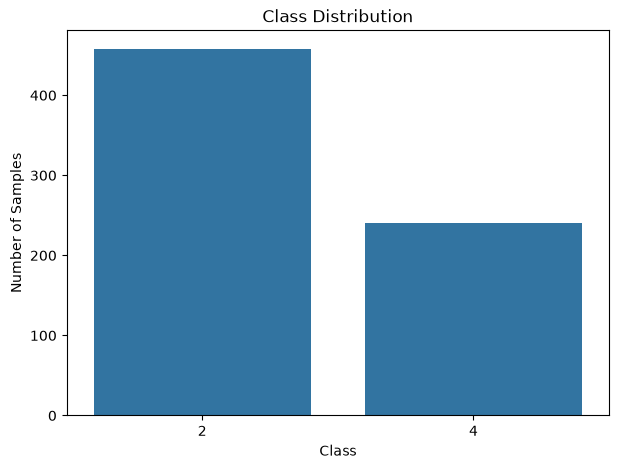

In [10]:
# ============================================
# STEP 7.2 - Visualize class distribution
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [11]:
# ============================================
# STEP 8.1 - Generate descriptive statistics
# ============================================

df[feature_columns].describe()

,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


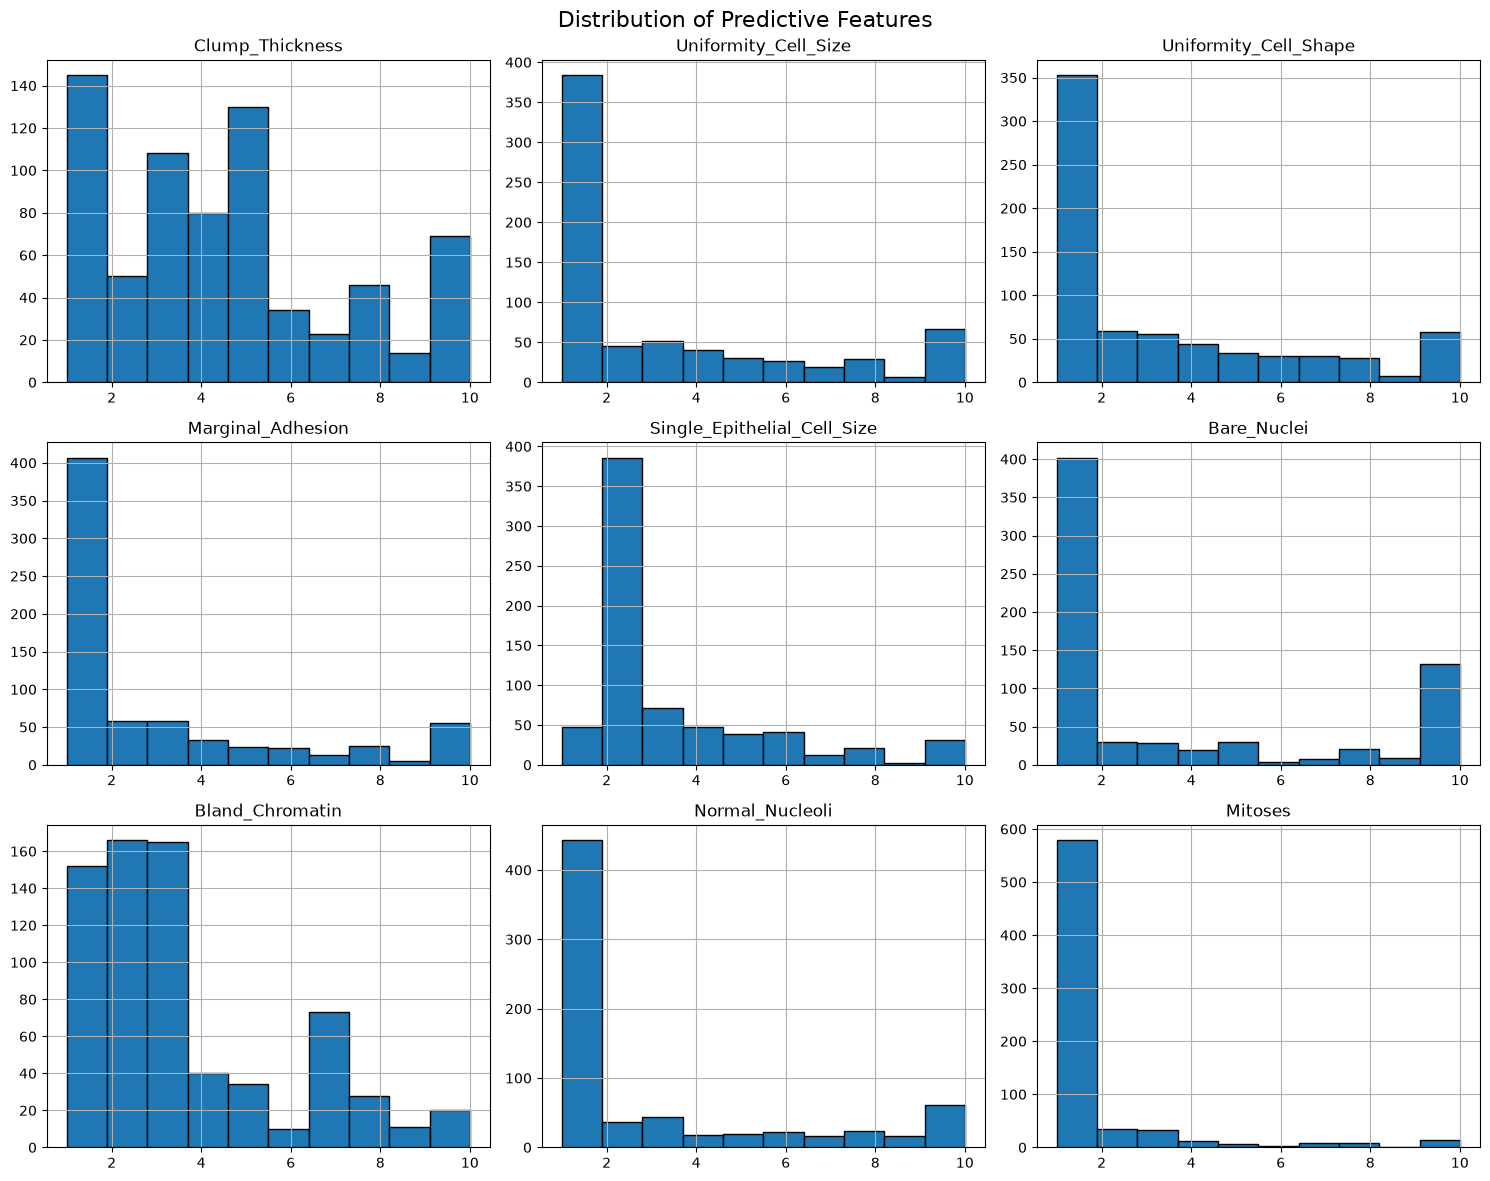

In [12]:
# ============================================
# STEP 9.1 - Plot histograms for all features
# ============================================

df[feature_columns].hist(
    figsize=(15, 12),
    bins=10,
    edgecolor="black"
)

plt.suptitle("Distribution of Predictive Features", fontsize=16)

plt.tight_layout()
plt.show()

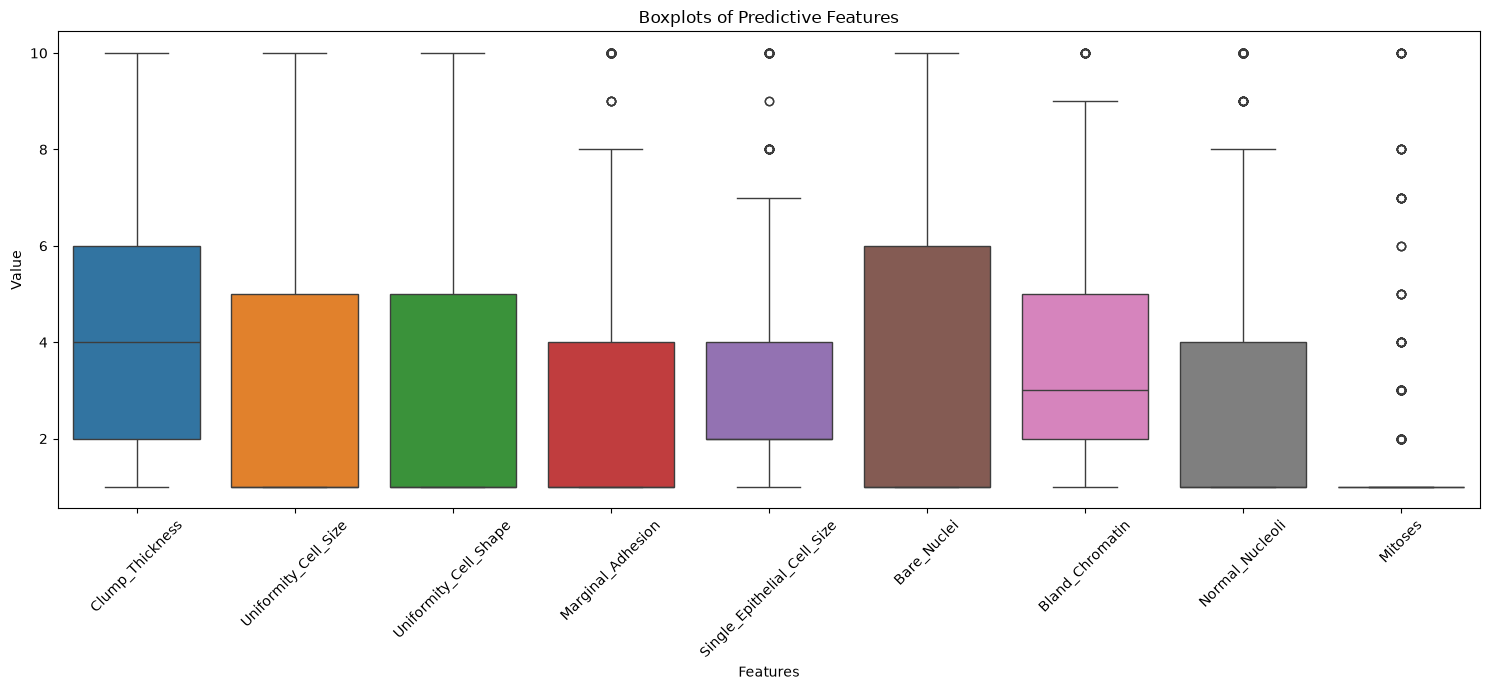

In [13]:
# ============================================
# STEP 10.1 - Create boxplots for the features
# ============================================

plt.figure(figsize=(15, 7))

sns.boxplot(data=df[feature_columns])

plt.title("Boxplots of Predictive Features")
plt.xlabel("Features")
plt.ylabel("Value")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

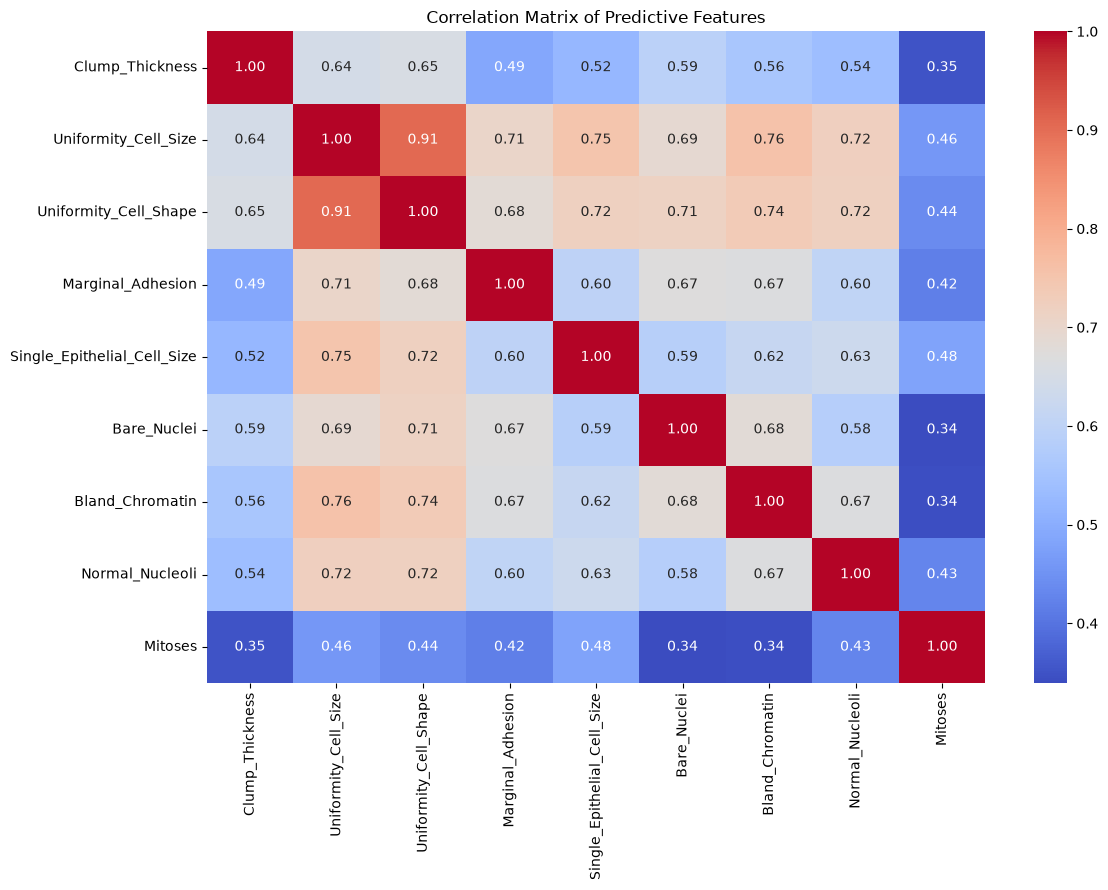

In [14]:
# ============================================
# STEP 11.1 - Create the correlation matrix
# ============================================

correlation_matrix = df[feature_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Predictive Features")

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# STEP 12.1 - Create readable class labels
# ============================================

df["Class_Label"] = df["Class"].map({
    2: "Benign",
    4: "Malignant"
})

df[["Class", "Class_Label"]].head()

,Class,Class_Label
0,2,Benign
1,2,Benign
2,2,Benign
3,2,Benign
4,2,Benign


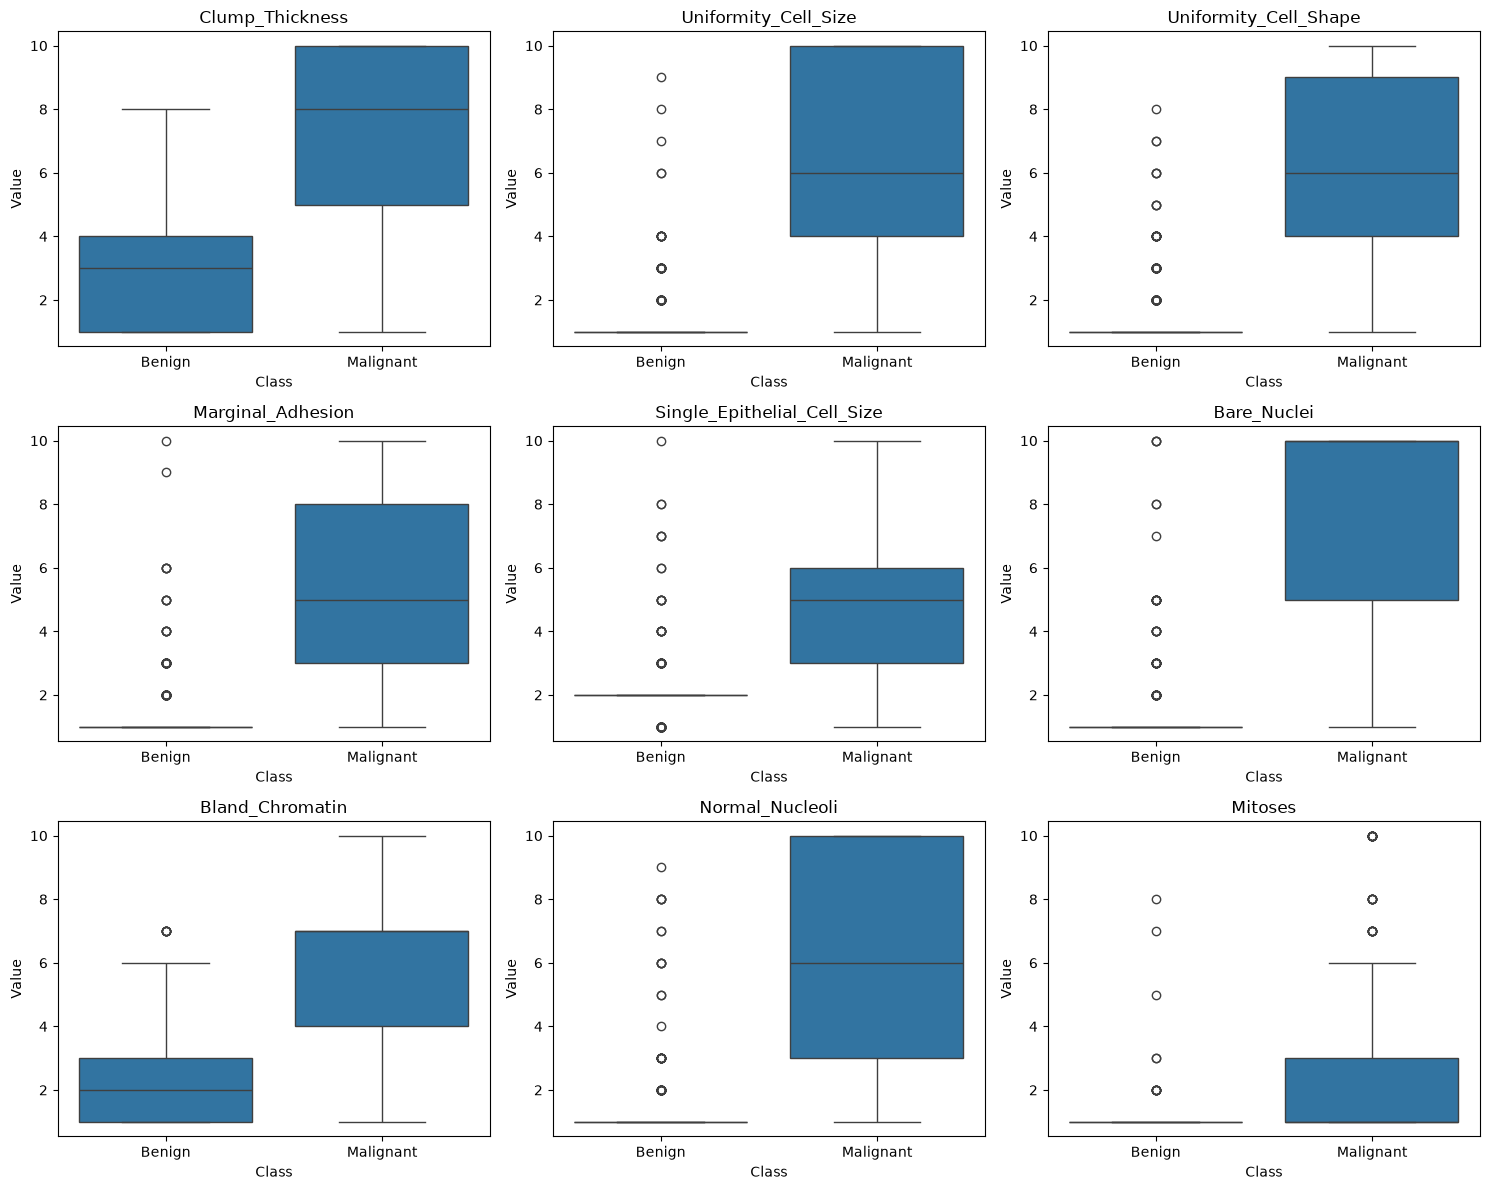

In [19]:
# ============================================
# STEP 13.1 - Compare feature distributions
# between benign and malignant classes
# ============================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flatten(), feature_columns):
    sns.boxplot(
        data=df,
        x="Class_Label",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Class")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [21]:
# ============================================
# STEP 14.1 - Save descriptive statistics
# ============================================

# Use the shared results/outputs folder from the main project directory.
OUTPUT_DIR = PROJECT_ROOT / "results" / "outputs"

# Create the output folder if it does not already exist.
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Calculate the mean of each feature for each class.
class_means = df.groupby("Class")[feature_columns].mean()

# Save the descriptive statistics to the shared output folder.
df[feature_columns].describe().to_csv(
    OUTPUT_DIR / "descriptive_statistics.csv"
)

# Save the class-wise feature means to the shared output folder.
class_means.to_csv(
    OUTPUT_DIR / "class_wise_means.csv"
)

# Confirm that the files were saved successfully.
print("Descriptive statistics saved successfully.")
print("Output folder:", OUTPUT_DIR)

Descriptive statistics saved successfully.
Output folder: c:\Users\gayan\Documents\AI\results\outputs


## EDA Summary

The exploratory data analysis was performed to understand the structure, distribution, variability, and relationships within the dataset.

The class distribution showed that benign cases were more common than malignant cases, indicating moderate class imbalance.

The histograms showed that several features were concentrated at lower values, with some features showing skewed distributions.

The boxplots identified some statistical outliers. However, the feature values remained within the valid measurement range of 1 to 10. Therefore, statistical outliers were not automatically removed because they may represent valid observations.

The correlation matrix showed strong positive relationships between several predictive features. The strongest relationship was between Uniformity of Cell Size and Uniformity of Cell Shape, with a correlation of approximately 0.91.

The class-wise analysis showed noticeable differences in the distributions of several features between benign and malignant cases, particularly Uniformity of Cell Size, Uniformity of Cell Shape, Bare Nuclei, and Clump Thickness.

These findings provided useful information for the later feature engineering and machine learning stages.


# Final Evaluation – Individual Model

## Member 02 – K-Nearest Neighbors (KNN) Classification

### Objective

The objective of this section is to develop a K-Nearest Neighbors (KNN)
classification model to classify breast cancer cases as:

- 0 = Benign
- 1 = Malignant

KNN classifies a new observation based on the classes of its nearest
neighbours.

Because KNN is a distance-based algorithm, feature scaling is important.
Therefore, StandardScaler is included inside the machine learning pipeline.

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Recall is particularly important because a false negative represents a
malignant case incorrectly classified as benign.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("KNN libraries imported successfully.")

KNN libraries imported successfully.


In [23]:
X = df.drop(columns=["Sample_ID", "Class"]).copy()

y = df["Class"].map({
    2: 0,   # Benign
    4: 1    # Malignant
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nMissing target values:", y.isna().sum())

X shape: (699, 10)
y shape: (699,)

Target distribution:
Class
0    458
1    241
Name: count, dtype: int64

Missing target values: 0


In [24]:
# ============================================================
# CHECK THE CURRENT DATASET BEFORE KNN MODELLING
# ============================================================

# Display the number of rows and columns currently in the dataframe
print("Current df shape:", df.shape)

# Display all column names
# This helps us confirm which columns are available for modelling
print("\nCurrent columns:")
print(df.columns.tolist())

# Count rows that are exact duplicates of previous rows
# We check this before removing anything
print("\nExact duplicate rows:")
print(df.duplicated().sum())

Current df shape: (699, 12)

Current columns:
['Sample_ID', 'Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class', 'Class_Label']

Exact duplicate rows:
8


In [25]:
# ============================================================
# INSPECT ALL ROWS INVOLVED IN DUPLICATE GROUPS
# ============================================================

# keep=False marks ALL copies of duplicated rows
# For example, if two identical rows exist, both rows are selected
duplicate_rows = df[df.duplicated(keep=False)]

# Display how many rows are involved in duplicate groups
print("Rows involved in duplicate groups:", len(duplicate_rows))

# Sort and display the duplicate rows
# This makes identical observations easier to compare
display(
    duplicate_rows.sort_values(
        by=df.columns.tolist()
    )
)

Rows involved in duplicate groups: 16


,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class,Class_Label
267,320675,3,3,5,2,3,10.0,7,1,1,4,Malignant
272,320675,3,3,5,2,3,10.0,7,1,1,4,Malignant
683,466906,1,1,1,1,2,1.0,1,1,1,2,Benign
684,466906,1,1,1,1,2,1.0,1,1,1,2,Benign
314,704097,1,1,1,1,1,1.0,2,1,1,2,Benign
338,704097,1,1,1,1,1,1.0,2,1,1,2,Benign
42,1100524,6,10,10,2,8,10.0,7,3,3,4,Malignant
253,1100524,6,10,10,2,8,10.0,7,3,3,4,Malignant
62,1116116,9,10,10,1,10,8.0,3,3,1,4,Malignant
254,1116116,9,10,10,1,10,8.0,3,3,1,4,Malignant


In [26]:
# ============================================================
# CREATE A CLEAN DATASET FOR MACHINE LEARNING
# ============================================================

# Create a separate copy for modelling.
# This keeps the original 'df' unchanged so the existing EDA
# section in Member 02's notebook is not affected.
model_df = df.copy()

# Remove the Class_Label column.
# Class_Label was created only to make EDA easier to understand.
# We do not use it as an input feature because it directly represents
# the target class and would cause data leakage.
model_df = model_df.drop(columns=["Class_Label"])

# Remove exact duplicate observations.
# keep="first" keeps the first occurrence and removes later identical copies.
model_df = model_df.drop_duplicates(keep="first").reset_index(drop=True)

# Display the final shape after duplicate removal.
print("Final modelling dataset shape:", model_df.shape)

# Check that no exact duplicates remain.
print("Remaining duplicate rows:", model_df.duplicated().sum())

# Display the class distribution after cleaning.
print("\nClass distribution:")
print(model_df["Class"].value_counts().sort_index())

Final modelling dataset shape: (691, 11)
Remaining duplicate rows: 0

Class distribution:
Class
2    453
4    238
Name: count, dtype: int64


In [27]:
# ============================================================
# PREPARE FEATURES (X) AND TARGET (y)
# ============================================================

# Create the feature matrix X.
#
# Sample_ID is removed because it is only an identifier for each sample
# and does not describe the characteristics of the tumour.
#
# Class is removed because it is the target variable that we want
# the KNN model to predict.
X = model_df.drop(columns=["Sample_ID", "Class"]).copy()

# Convert the original class values into binary labels:
# 2 = Benign    -> 0
# 4 = Malignant -> 1
#
# Using 0 and 1 makes the target suitable for binary classification.
y = model_df["Class"].map({
    2: 0,   # Benign
    4: 1    # Malignant
})

# Display the dimensions of X and y.
print("X shape:", X.shape)
print("y shape:", y.shape)

# Display the target distribution.
# 0 should represent benign cases and 1 malignant cases.
print("\nTarget distribution:")
print(y.value_counts().sort_index())

# Check that target encoding did not create any missing values.
print("\nMissing target values:", y.isna().sum())

# Display the actual feature names used by KNN.
print("\nFeatures used for modelling:")
print(X.columns.tolist())

X shape: (691, 9)
y shape: (691,)

Target distribution:
Class
0    453
1    238
Name: count, dtype: int64

Missing target values: 0

Features used for modelling:
['Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses']


In [28]:
# ============================================================
# SPLIT THE DATA INTO TRAINING AND TESTING SETS
# ============================================================

# Split the dataset:
# 80% -> training data
# 20% -> testing data
#
# random_state=42:
# Ensures that we get the same split every time the code is executed.
#
# stratify=y:
# Maintains approximately the same benign/malignant class proportion
# in both the training and testing datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the size of the complete dataset.
print("Full dataset :", len(X))

# Display training and testing dimensions.
print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)

# Display class distribution in the training dataset.
print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

# Display class distribution in the testing dataset.
print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

# Verify that every observation belongs to either training or testing data.
print("\nTrain + Test :", len(X_train) + len(X_test))

Full dataset : 691
Training set : (552, 9)
Testing set  : (139, 9)

Training target distribution:
Class
0    362
1    190
Name: count, dtype: int64

Testing target distribution:
Class
0    91
1    48
Name: count, dtype: int64

Train + Test : 691


## Baseline KNN Model

A baseline K-Nearest Neighbors model is first trained using the default
hyperparameters.

The pipeline contains three stages:

1. **Median Imputation** – replaces missing feature values using the median
   calculated from the training data.
2. **StandardScaler** – standardizes the features because KNN uses distances
   between observations.
3. **KNN Classifier** – classifies an observation based on its nearest
   neighbours.

The baseline model provides a reference point before hyperparameter tuning.

In [29]:
# ============================================================
# CREATE THE BASELINE KNN PIPELINE
# ============================================================

# Create a machine learning pipeline.
#
# A pipeline ensures that preprocessing and modelling are performed
# in the correct order.
#
# IMPORTANT:
# The imputer and scaler are fitted only using the training data.
# This helps prevent information from the test set leaking into
# the training process.
knn_pipeline = Pipeline([
    
    # Step 1:
    # Replace missing values using the median of each feature.
    # This is especially important because Bare_Nuclei contains
    # missing values in the original dataset.
    ("imputer", SimpleImputer(strategy="median")),
    
    # Step 2:
    # Standardize every feature so that the features have
    # comparable scales.
    #
    # Scaling is very important for KNN because KNN calculates
    # distances between observations.
    ("scaler", StandardScaler()),
    
    # Step 3:
    # Create the KNN classifier.
    #
    # The default KNeighborsClassifier uses:
    # n_neighbors = 5
    # weights = "uniform"
    # metric = "minkowski"
    # p = 2, which corresponds to Euclidean distance.
    ("model", KNeighborsClassifier())
])

# Train the complete pipeline using only the training dataset.
knn_pipeline.fit(X_train, y_train)

print("Baseline KNN model trained successfully.")

Baseline KNN model trained successfully.


### Baseline KNN – Test Set Evaluation

The baseline model is evaluated using the unseen test dataset.

The following metrics are calculated:

- **Accuracy** – overall percentage of correct predictions.
- **Precision** – proportion of predicted malignant cases that are actually malignant.
- **Recall** – proportion of actual malignant cases correctly identified.
- **F1-score** – balance between precision and recall.
- **ROC-AUC** – ability of the model to distinguish between benign and malignant cases.

For this problem, recall is particularly important because a false negative
means that a malignant case has been predicted as benign.

In [30]:
# ============================================================
# EVALUATE THE BASELINE KNN MODEL ON THE TEST SET
# ============================================================

# Predict the class (0 or 1) for each observation in the test dataset.
y_pred_knn_baseline = knn_pipeline.predict(X_test)

# Obtain the probability of the positive class (malignant = 1).
#
# predict_proba() returns probabilities for both classes.
# [:, 1] selects the probability of Class 1 (malignant).
y_prob_knn_baseline = knn_pipeline.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# CALCULATE PERFORMANCE METRICS
# ------------------------------------------------------------

# Accuracy:
# Percentage of all test observations classified correctly.
knn_baseline_accuracy = accuracy_score(
    y_test,
    y_pred_knn_baseline
)

# Precision:
# Out of all cases predicted as malignant,
# how many were actually malignant?
knn_baseline_precision = precision_score(
    y_test,
    y_pred_knn_baseline
)

# Recall:
# Out of all actual malignant cases,
# how many were correctly detected?
knn_baseline_recall = recall_score(
    y_test,
    y_pred_knn_baseline
)

# F1-score:
# Harmonic mean of precision and recall.
knn_baseline_f1 = f1_score(
    y_test,
    y_pred_knn_baseline
)

# ROC-AUC:
# Measures how well the model separates the two classes
# across different classification thresholds.
knn_baseline_roc_auc = roc_auc_score(
    y_test,
    y_prob_knn_baseline
)


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("Baseline KNN Test Results")
print("-" * 35)

print(f"Accuracy  : {knn_baseline_accuracy:.4f}")
print(f"Precision : {knn_baseline_precision:.4f}")
print(f"Recall    : {knn_baseline_recall:.4f}")
print(f"F1-score  : {knn_baseline_f1:.4f}")
print(f"ROC-AUC   : {knn_baseline_roc_auc:.4f}")

Baseline KNN Test Results
-----------------------------------
Accuracy  : 0.9568
Precision : 0.9773
Recall    : 0.8958
F1-score  : 0.9348
ROC-AUC   : 0.9828


In [31]:
# ============================================================
# BASELINE KNN CONFUSION MATRIX
# ============================================================

# Create the confusion matrix.
#
# Layout:
#
#                 Predicted
#               Benign  Malignant
# Actual Benign    TN       FP
# Actual Malignant FN       TP
#
# TN = correctly predicted benign cases
# FP = benign cases incorrectly predicted as malignant
# FN = malignant cases incorrectly predicted as benign
# TP = correctly predicted malignant cases
knn_baseline_cm = confusion_matrix(
    y_test,
    y_pred_knn_baseline
)

print("Baseline KNN Confusion Matrix:")
print(knn_baseline_cm)

# Extract each value from the confusion matrix.
tn, fp, fn, tp = knn_baseline_cm.ravel()

print("\nConfusion Matrix Details")
print("-" * 35)

print("True Negatives  (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives  (TP):", tp)


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

# Display precision, recall, F1-score and support
# separately for benign and malignant classes.
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_knn_baseline,
        target_names=["Benign", "Malignant"]
    )
)

Baseline KNN Confusion Matrix:
[[90  1]
 [ 5 43]]

Confusion Matrix Details
-----------------------------------
True Negatives  (TN): 90
False Positives (FP): 1
False Negatives (FN): 5
True Positives  (TP): 43

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        91
   Malignant       0.98      0.90      0.93        48

    accuracy                           0.96       139
   macro avg       0.96      0.94      0.95       139
weighted avg       0.96      0.96      0.96       139



## Baseline KNN – 5-Fold Cross-Validation

Stratified 5-fold cross-validation is used to evaluate the stability of the
baseline KNN model.

The training dataset is divided into five folds. The model is trained using
four folds and validated using the remaining fold. This process is repeated
five times.

`StratifiedKFold` maintains approximately the same proportion of benign and
malignant cases in each fold.

The test dataset is not used during cross-validation.

In [32]:
# ============================================================
# CREATE STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

# n_splits=5:
# Divide the training dataset into five folds.
#
# shuffle=True:
# Shuffle observations before creating the folds.
#
# random_state=42:
# Makes the folds reproducible.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# DEFINE THE EVALUATION METRICS
# ============================================================

# Evaluate the model using multiple metrics.
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# ============================================================
# PERFORM CROSS-VALIDATION
# ============================================================

# cross_validate repeatedly trains and validates the complete
# KNN pipeline using the five folds.
#
# Importantly, imputation and scaling occur separately inside
# each training fold, which helps avoid data leakage.
cv_results_knn = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)


# ============================================================
# DISPLAY CROSS-VALIDATION RESULTS
# ============================================================

print("Baseline KNN - 5-Fold Cross-Validation")
print("-" * 50)

# Loop through every evaluation metric.
for metric in scoring.keys():

    # cross_validate stores test results using the name
    # "test_" followed by the metric name.
    scores = cv_results_knn[f"test_{metric}"]

    # Display the mean performance across the five folds
    # together with its standard deviation.
    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Baseline KNN - 5-Fold Cross-Validation
--------------------------------------------------
ACCURACY  : 0.9620 ± 0.0120
PRECISION : 0.9431 ± 0.0236
RECALL    : 0.9474 ± 0.0288
F1        : 0.9448 ± 0.0172
ROC_AUC   : 0.9837 ± 0.0141


## KNN Hyperparameter Tuning

The baseline KNN model uses the default configuration. However, the performance
of KNN depends strongly on how neighbours and distances are defined.

The following hyperparameters are investigated:

- **n_neighbors** – the number of neighbouring observations considered when
  making a prediction.
- **weights** – determines whether all neighbours have equal influence or
  closer neighbours have greater influence.
- **metric** – determines how distance between observations is calculated.
- **p** – controls the Minkowski distance:
  - p = 1 represents Manhattan distance.
  - p = 2 represents Euclidean distance.

GridSearchCV is used to test multiple combinations using stratified 5-fold
cross-validation.

F1-score is used as the primary tuning metric because it balances precision
and recall.

In [33]:
# ============================================================
# DEFINE KNN HYPERPARAMETER SEARCH SPACE
# ============================================================

# Define different values for the number of neighbours.
#
# Small k:
# The model reacts more strongly to nearby observations
# and may become sensitive to noise.
#
# Large k:
# The decision becomes smoother, but too large a value
# may hide important local patterns.
n_neighbors_values = [3, 5, 7, 9, 11, 15, 21]


# Define the complete parameter grid.
knn_param_grid = [

    # --------------------------------------------------------
    # VARIETY 1: MINKOWSKI DISTANCE
    # --------------------------------------------------------
    {
        # Number of neighbours used for classification.
        "model__n_neighbors": n_neighbors_values,

        # "uniform":
        # Every neighbour has the same voting power.
        #
        # "distance":
        # Closer neighbours receive greater voting power.
        "model__weights": ["uniform", "distance"],

        # Minkowski is a general distance metric.
        "model__metric": ["minkowski"],

        # p=1 -> Manhattan distance
        # p=2 -> Euclidean distance
        "model__p": [1, 2]
    },


    # --------------------------------------------------------
    # VARIETY 2: CHEBYSHEV DISTANCE
    # --------------------------------------------------------
    {
        # Test the same numbers of neighbours.
        "model__n_neighbors": n_neighbors_values,

        # Compare equal voting and distance-based voting.
        "model__weights": ["uniform", "distance"],

        # Chebyshev uses the largest difference between
        # corresponding feature values as the distance.
        "model__metric": ["chebyshev"]
    }
]


# ============================================================
# COUNT THE NUMBER OF PARAMETER COMBINATIONS
# ============================================================

# Minkowski:
# 7 neighbour values × 2 weights × 2 p values = 28
#
# Chebyshev:
# 7 neighbour values × 2 weights = 14
#
# Total = 42 different KNN configurations.
number_of_combinations = (
    len(n_neighbors_values) * 2 * 2
    +
    len(n_neighbors_values) * 2
)

print("Total KNN configurations:", number_of_combinations)

# With 5-fold cross-validation:
# 42 configurations × 5 folds = 210 model fits.
print(
    "Total model fits with 5-fold CV:",
    number_of_combinations * 5
)

Total KNN configurations: 42
Total model fits with 5-fold CV: 210


In [34]:
# ============================================================
# CREATE GRIDSEARCHCV FOR KNN
# ============================================================

# GridSearchCV systematically evaluates every hyperparameter
# combination defined in knn_param_grid.
#
# estimator:
# Uses our complete pipeline containing:
# median imputation -> scaling -> KNN.
#
# scoring="f1":
# F1-score is used to select the best model because it balances
# precision and recall.
#
# cv=cv:
# Uses the same stratified 5-fold cross-validation strategy.
#
# n_jobs=-1:
# Uses all available CPU cores to make the search faster.
#
# return_train_score=True:
# Stores training scores as well as validation scores.
# These can later help us inspect possible overfitting.
knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)


# ============================================================
# RUN THE HYPERPARAMETER SEARCH
# ============================================================

# Fit GridSearchCV using ONLY the training dataset.
#
# The held-out test set is not used during tuning.
knn_grid_search.fit(
    X_train,
    y_train
)


# ============================================================
# DISPLAY THE BEST CONFIGURATION
# ============================================================

print("KNN Grid Search Completed")
print("-" * 45)

# Display the hyperparameter combination that achieved
# the highest mean validation F1-score.
print("Best parameters:")
print(knn_grid_search.best_params_)

# Display the corresponding mean cross-validation F1-score.
print(
    "\nBest CV F1-score:",
    round(knn_grid_search.best_score_, 4)
)

KNN Grid Search Completed
---------------------------------------------
Best parameters:
{'model__metric': 'minkowski', 'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'uniform'}

Best CV F1-score: 0.9555


In [35]:
# ============================================================
# INSPECT GRID SEARCH RESULTS
# ============================================================

# Convert all GridSearchCV results into a DataFrame.
knn_grid_results = pd.DataFrame(
    knn_grid_search.cv_results_
)


# Select the most useful columns for comparison.
knn_top_results = knn_grid_results[
    [
        "param_model__n_neighbors",
        "param_model__weights",
        "param_model__metric",
        "param_model__p",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()


# Sort configurations according to their validation ranking.
# Rank 1 represents the best configuration.
knn_top_results = knn_top_results.sort_values(
    by="rank_test_score"
)


# Display the 10 best KNN configurations.
print("Top 10 KNN Hyperparameter Configurations:")

display(
    knn_top_results.head(10)
)

Top 10 KNN Hyperparameter Configurations:


,param_model__n_neighbors,param_model__weights,param_model__metric,param_model__p,mean_train_score,mean_test_score,std_test_score,rank_test_score
10,7,uniform,minkowski,2.0,0.957432,0.955490,0.013740,1
11,7,distance,minkowski,2.0,1.000000,0.955490,0.013740,1
23,15,distance,minkowski,2.0,1.000000,0.952737,0.010882,3
22,15,uniform,minkowski,2.0,0.952164,0.952737,0.010882,3
15,9,distance,minkowski,2.0,1.000000,0.952679,0.013966,5
14,9,uniform,minkowski,2.0,0.956279,0.952679,0.013966,5
1,3,distance,minkowski,1.0,1.000000,0.950082,0.022409,7
13,9,distance,minkowski,1.0,1.000000,0.949945,0.013388,8
17,11,distance,minkowski,1.0,1.000000,0.949945,0.013388,8
16,11,uniform,minkowski,1.0,0.952038,0.949945,0.013388,8


In [36]:
# ============================================================
# GET THE BEST TUNED KNN MODEL
# ============================================================

# best_estimator_ contains the complete pipeline using the
# best hyperparameters discovered by GridSearchCV.
best_knn_model = knn_grid_search.best_estimator_


# ============================================================
# MAKE TEST-SET PREDICTIONS
# ============================================================

# Predict benign/malignant classes for the held-out test data.
y_pred_knn_tuned = best_knn_model.predict(
    X_test
)

# Obtain malignant-class probabilities for ROC-AUC.
y_prob_knn_tuned = best_knn_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# CALCULATE TUNED MODEL PERFORMANCE
# ============================================================

knn_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_knn_tuned
)

knn_tuned_precision = precision_score(
    y_test,
    y_pred_knn_tuned
)

knn_tuned_recall = recall_score(
    y_test,
    y_pred_knn_tuned
)

knn_tuned_f1 = f1_score(
    y_test,
    y_pred_knn_tuned
)

knn_tuned_roc_auc = roc_auc_score(
    y_test,
    y_prob_knn_tuned
)


# ============================================================
# DISPLAY TUNED TEST RESULTS
# ============================================================

print("Tuned KNN Test Results")
print("-" * 35)

print(f"Accuracy  : {knn_tuned_accuracy:.4f}")
print(f"Precision : {knn_tuned_precision:.4f}")
print(f"Recall    : {knn_tuned_recall:.4f}")
print(f"F1-score  : {knn_tuned_f1:.4f}")
print(f"ROC-AUC   : {knn_tuned_roc_auc:.4f}")

Tuned KNN Test Results
-----------------------------------
Accuracy  : 0.9640
Precision : 0.9778
Recall    : 0.9167
F1-score  : 0.9462
ROC-AUC   : 0.9823


In [37]:
# ============================================================
# TUNED KNN CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix for the tuned model.
knn_tuned_cm = confusion_matrix(
    y_test,
    y_pred_knn_tuned
)

print("Tuned KNN Confusion Matrix:")
print(knn_tuned_cm)


# Extract TN, FP, FN and TP.
tn_tuned, fp_tuned, fn_tuned, tp_tuned = (
    knn_tuned_cm.ravel()
)


# Display each value separately.
print("\nConfusion Matrix Details")
print("-" * 35)

print("True Negatives  (TN):", tn_tuned)
print("False Positives (FP):", fp_tuned)
print("False Negatives (FN):", fn_tuned)
print("True Positives  (TP):", tp_tuned)


# ============================================================
# TUNED CLASSIFICATION REPORT
# ============================================================

# Display class-specific precision, recall and F1-score.
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_knn_tuned,
        target_names=["Benign", "Malignant"]
    )
)

Tuned KNN Confusion Matrix:
[[90  1]
 [ 4 44]]

Confusion Matrix Details
-----------------------------------
True Negatives  (TN): 90
False Positives (FP): 1
False Negatives (FN): 4
True Positives  (TP): 44

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        91
   Malignant       0.98      0.92      0.95        48

    accuracy                           0.96       139
   macro avg       0.97      0.95      0.96       139
weighted avg       0.96      0.96      0.96       139



## Baseline vs Tuned KNN Comparison

The baseline and tuned KNN models are compared using the same held-out test
dataset.

Hyperparameter tuning improved accuracy, recall, and F1-score. In particular,
the number of false negatives decreased from 5 to 4, meaning the tuned model
correctly identified one additional malignant case.

The ROC-AUC decreased slightly, showing that tuning does not necessarily
improve every evaluation metric.

In [38]:
# ============================================================
# COMPARE BASELINE AND TUNED KNN MODELS
# ============================================================

# Create a DataFrame containing the test-set performance
# of both the baseline and tuned KNN models.
knn_comparison = pd.DataFrame({
    "Model": [
        "KNN - Baseline",
        "KNN - Tuned"
    ],

    # Overall classification accuracy.
    "Accuracy": [
        knn_baseline_accuracy,
        knn_tuned_accuracy
    ],

    # Precision for the malignant class.
    "Precision": [
        knn_baseline_precision,
        knn_tuned_precision
    ],

    # Recall for the malignant class.
    "Recall": [
        knn_baseline_recall,
        knn_tuned_recall
    ],

    # Balance between precision and recall.
    "F1": [
        knn_baseline_f1,
        knn_tuned_f1
    ],

    # Ability to distinguish benign from malignant cases
    # across different classification thresholds.
    "ROC_AUC": [
        knn_baseline_roc_auc,
        knn_tuned_roc_auc
    ],

    # Number of malignant cases incorrectly classified as benign.
    "False_Negatives": [
        fn,
        fn_tuned
    ]
})

# Round the numerical results to four decimal places
# to make the table easier to read.
knn_comparison = knn_comparison.round(4)

print("Baseline vs Tuned KNN Comparison:")

display(knn_comparison)

Baseline vs Tuned KNN Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,False_Negatives
0,KNN - Baseline,0.9568,0.9773,0.8958,0.9348,0.9828,5
1,KNN - Tuned,0.9640,0.9778,0.9167,0.9462,0.9823,4


In [39]:
# ============================================================
# 5-FOLD CROSS-VALIDATION OF THE TUNED KNN MODEL
# ============================================================

# Evaluate the best KNN pipeline using the same stratified
# 5-fold cross-validation strategy used for the baseline model.
#
# Only the training dataset is used here.
# The held-out test set remains separate.
cv_results_knn_tuned = cross_validate(
    best_knn_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)


# ============================================================
# DISPLAY TUNED CROSS-VALIDATION RESULTS
# ============================================================

print("Tuned KNN - 5-Fold Cross-Validation")
print("-" * 50)

# Calculate and display the mean and standard deviation
# for each evaluation metric across the five folds.
for metric in scoring.keys():

    # Get the five validation scores for the current metric.
    scores = cv_results_knn_tuned[f"test_{metric}"]

    # Display average performance and variation between folds.
    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Tuned KNN - 5-Fold Cross-Validation
--------------------------------------------------
ACCURACY  : 0.9692 ± 0.0092
PRECISION : 0.9485 ± 0.0152
RECALL    : 0.9632 ± 0.0268
F1        : 0.9555 ± 0.0137
ROC_AUC   : 0.9848 ± 0.0141


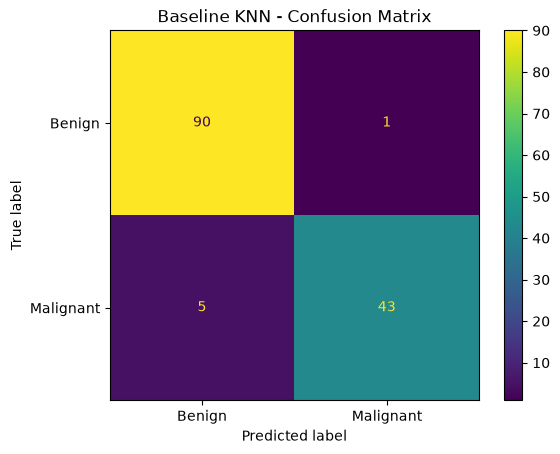

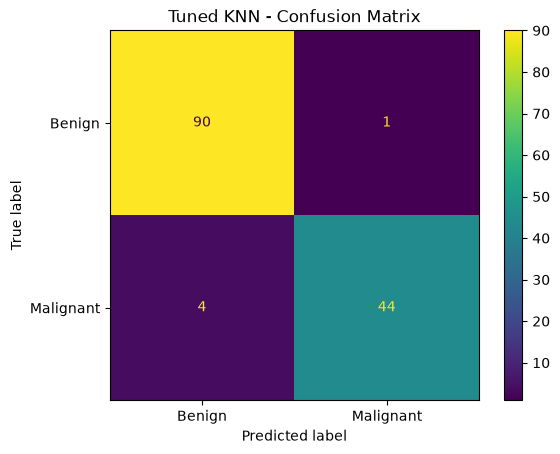

In [40]:
# ============================================================
# VISUALIZE BASELINE AND TUNED CONFUSION MATRICES
# ============================================================

# Create the baseline confusion matrix display.
baseline_display = ConfusionMatrixDisplay(
    confusion_matrix=knn_baseline_cm,
    display_labels=["Benign", "Malignant"]
)

# Plot the baseline confusion matrix.
baseline_display.plot()

# Add a clear title.
plt.title("Baseline KNN - Confusion Matrix")

# Display the figure.
plt.show()


# ------------------------------------------------------------


# Create the tuned confusion matrix display.
tuned_display = ConfusionMatrixDisplay(
    confusion_matrix=knn_tuned_cm,
    display_labels=["Benign", "Malignant"]
)

# Plot the tuned confusion matrix.
tuned_display.plot()

# Add a clear title.
plt.title("Tuned KNN - Confusion Matrix")

# Display the figure.
plt.show()

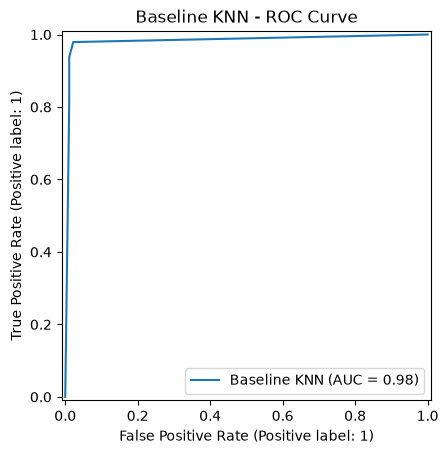

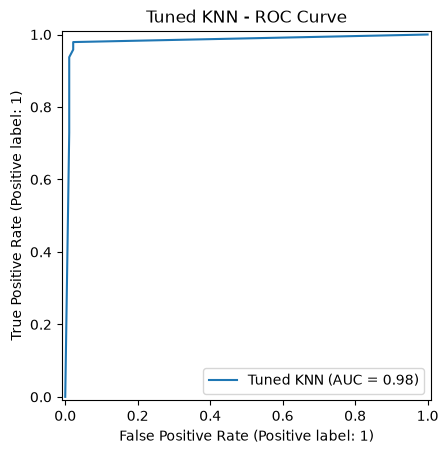

In [41]:
# ============================================================
# ROC CURVE - BASELINE KNN
# ============================================================

# Plot the ROC curve using the baseline model's
# predicted malignant-class probabilities.
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_knn_baseline,
    name="Baseline KNN"
)

# Add a descriptive title.
plt.title("Baseline KNN - ROC Curve")

# Display the plot.
plt.show()


# ============================================================
# ROC CURVE - TUNED KNN
# ============================================================

# Plot the ROC curve using the tuned model's
# predicted malignant-class probabilities.
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_knn_tuned,
    name="Tuned KNN"
)

# Add a descriptive title.
plt.title("Tuned KNN - ROC Curve")

# Display the plot.
plt.show()

## Final Conclusion – Member 02

K-Nearest Neighbors was selected as the individual classification model for
Member 02. KNN is suitable for this dataset because the problem is a binary
classification task with numerical predictive features.

Because KNN is a distance-based algorithm, median imputation and
StandardScaler were included inside the machine learning pipeline. Keeping
these preprocessing operations inside the pipeline also helps prevent data
leakage during cross-validation.

The baseline KNN model achieved an accuracy of **0.9568**, precision of
**0.9773**, recall of **0.8958**, F1-score of **0.9348**, and ROC-AUC of
**0.9828** on the held-out test set. It produced 5 false negatives.

A total of **42 KNN hyperparameter configurations** were evaluated using
stratified 5-fold cross-validation, resulting in **210 model fits**.
The search investigated different numbers of neighbours, weighting
strategies, and distance measures.

The optimum configuration used:

- `n_neighbors = 7`
- `weights = uniform`
- `metric = minkowski`
- `p = 2`, representing Euclidean distance

The best cross-validation F1-score during hyperparameter tuning was
**0.9555**.

The tuned KNN achieved an accuracy of **0.9640**, precision of **0.9778**,
recall of **0.9167**, F1-score of **0.9462**, and ROC-AUC of **0.9823** on
the held-out test set.

Compared with the baseline model, tuning increased recall from **0.8958 to
0.9167** and reduced false negatives from **5 to 4**. Therefore, the tuned
KNN configuration was retained as Member 02's optimum model for the final
group-level comparison.

Although KNN produced strong results, it has several limitations. Its
predictions depend on the selected distance measure and number of neighbours,
and feature scaling is essential. Prediction can also become computationally
expensive for much larger datasets because distances to training observations
must be calculated when making predictions.

Possible future improvements include evaluating additional distance metrics,
testing feature-selection or dimensionality-reduction approaches, evaluating
the model on a larger external dataset, and investigating classification
thresholds according to the relative cost of false negatives and false
positives.

In [42]:
# ============================================================
# SAVE MEMBER 02 FINAL-EVALUATION RESULTS
# ============================================================

# Create a dedicated Member 02 folder inside the shared
# results/outputs directory required by the repository structure.
output_dir = (
    PROJECT_ROOT
    / "results"
    / "outputs"
    / "member_02"
)

# Create the directory if it does not already exist.
output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# SAVE BASELINE VS TUNED COMPARISON
# ------------------------------------------------------------

# Save the main test-set comparison table.
knn_comparison.to_csv(
    output_dir / "knn_baseline_vs_tuned.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE ALL GRID SEARCH RESULTS
# ------------------------------------------------------------

# Save all 42 tested KNN hyperparameter configurations.
knn_grid_results.to_csv(
    output_dir / "knn_grid_search_results.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE TOP HYPERPARAMETER CONFIGURATIONS
# ------------------------------------------------------------

# Save the strongest KNN hyperparameter configurations
# for later comparison and review.
knn_top_results.to_csv(
    output_dir / "knn_top_configurations.csv",
    index=False
)


# ------------------------------------------------------------
# CREATE AND SAVE CROSS-VALIDATION SUMMARY
# ------------------------------------------------------------

# Create a table containing the mean and standard deviation
# of each metric for baseline and tuned KNN.
cv_summary = []

for model_name, results in [
    ("KNN - Baseline", cv_results_knn),
    ("KNN - Tuned", cv_results_knn_tuned)
]:

    row = {"Model": model_name}

    # Store the mean and standard deviation for every metric.
    for metric in scoring.keys():

        scores = results[f"test_{metric}"]

        row[f"{metric}_mean"] = scores.mean()
        row[f"{metric}_std"] = scores.std()

    cv_summary.append(row)


# Convert the summary into a DataFrame.
knn_cv_summary = pd.DataFrame(cv_summary)


# Save the cross-validation summary.
knn_cv_summary.to_csv(
    output_dir / "knn_cross_validation_summary.csv",
    index=False
)


# ------------------------------------------------------------
# CONFIRM SUCCESS
# ------------------------------------------------------------

# Confirm where the final Member 02 files were saved.
print("Member 02 results saved successfully.")
print("Output folder:", output_dir)

print("\nSaved files:")

# Display all files currently stored in the Member 02 folder.
for file in output_dir.iterdir():
    print(file.name)

Member 02 results saved successfully.
Output folder: c:\Users\gayan\Documents\AI\results\outputs\member_02

Saved files:
knn_baseline_vs_tuned.csv
knn_cross_validation_summary.csv
knn_grid_search_results.csv
knn_top_configurations.csv


In [43]:
# Import Path for safe file and folder handling.
from pathlib import Path

# Detect the folder where the notebook is currently running.
CURRENT_DIR = Path.cwd()

# If running from the "notebooks" folder,
# move one level up to reach the main project folder.
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Create the path to the shared raw dataset.
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "breast-cancer-wisconsin.data"
)

# Verify that the correct project and dataset paths were detected.
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Users\gayan\Documents\AI
Dataset path: c:\Users\gayan\Documents\AI\data\raw\breast-cancer-wisconsin.data
Dataset exists: True
